In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score

# Plotting Importance
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# Import Train and Test CSV

In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [4]:
train = pd.get_dummies(train, drop_first=True)
train.head()

,AGE,HB,TLC,PLATELETS,GLUCOSE,UREA,CREATININE,EF,GENDER_M,RURAL_U,TYPE_OF_ADMISSION_EMERGENCY_OPD_O,LIFESTYLE_RISK_yes,CHRONIC_CARDIO_yes,ACUTE_CARDIO_yes,ARRHYTHMIA_CONDUCTION_yes,NON_CARDIAC_COMORBID_yes,OTHER_CARDIO_yes,ICU_stay_yes,DOS_Short
0,65,46,437,64,15,98,71,30,True,False,False,True,True,False,True,False,True,False,True
1,53,9,77,267,91,320,232,23,True,True,False,False,True,False,False,True,False,False,True
2,67,37,449,219,33,190,41,30,False,True,False,False,True,False,False,False,True,False,False
3,56,42,49,83,186,198,41,17,False,True,False,False,True,True,False,True,True,False,False
4,47,34,443,266,62,212,81,33,True,True,False,True,False,False,False,True,True,False,False


In [5]:
X = train.drop(columns=['DOS_Short'])
y = train['DOS_Short']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
mlp1 = MLPClassifier(hidden_layer_sizes=(3,3), max_iter=1000, random_state=0, solver='sgd', verbose=True,
                    alpha=0.1, momentum=0.9, batch_size=32, learning_rate='adaptive')
mlp1.fit(X_train_scaled, y_train)

Iteration 1, loss = 0.76297974
Iteration 2, loss = 0.71705657
Iteration 3, loss = 0.70031899
Iteration 4, loss = 0.68928216
Iteration 5, loss = 0.67998041
Iteration 6, loss = 0.67231603
Iteration 7, loss = 0.66603265
Iteration 8, loss = 0.66006124
Iteration 9, loss = 0.65454046
Iteration 10, loss = 0.64960960
Iteration 11, loss = 0.64509950
Iteration 12, loss = 0.64109400
Iteration 13, loss = 0.63743441
Iteration 14, loss = 0.63411539
Iteration 15, loss = 0.63110105
Iteration 16, loss = 0.62853876
Iteration 17, loss = 0.62618674
Iteration 18, loss = 0.62420725
Iteration 19, loss = 0.62247759
Iteration 20, loss = 0.62107176
Iteration 21, loss = 0.61988497
Iteration 22, loss = 0.61878070
Iteration 23, loss = 0.61780114
Iteration 24, loss = 0.61704685
Iteration 25, loss = 0.61621349
Iteration 26, loss = 0.61552586
Iteration 27, loss = 0.61478893
Iteration 28, loss = 0.61415798
Iteration 29, loss = 0.61358138
Iteration 30, loss = 0.61300858
Iteration 31, loss = 0.61244905
Iteration 32, los

MLPClassifier(alpha=0.1, batch_size=32, hidden_layer_sizes=(3, 3),
              learning_rate='adaptive', max_iter=1000, random_state=0,
              solver='sgd', verbose=True)

In [8]:
import plotly.graph_objects as go

def plot_nn_architecture(model, X_train):
    # Get number of neurons in each layer
    layer_sizes = [X_train.shape[1]] + list(model.hidden_layer_sizes) + [1]  # Input, hidden, output layers

    fig = go.Figure()

    # Plot nodes for each layer
    for i, size in enumerate(layer_sizes):
        for j in range(size):
            if i == 0:  # Input layer
                text = X_train.columns[j]
            else:
                text = f'Layer {i} Node {j+1}'
            
            fig.add_trace(go.Scatter(
                x=[i], y=[j], mode='markers+text', text=text,
                marker=dict(size=10), textposition="top center"))

    # Plot connections
    for i in range(len(layer_sizes) - 1):
        for j in range(layer_sizes[i]):
            for k in range(layer_sizes[i + 1]):
                fig.add_trace(go.Scatter(
                    x=[i, i + 1], y=[j, k], mode='lines', line=dict(width=0.5, color='gray')))

    fig.update_layout(
        title="Neural Network Architecture",
        showlegend=False,
        xaxis=dict(showgrid=False, zeroline=False),
        yaxis=dict(showgrid=False, zeroline=False),
        plot_bgcolor='white'
    )

    fig.write_html('neural_network_architecture.html')

plot_nn_architecture(mlp1, X_train)


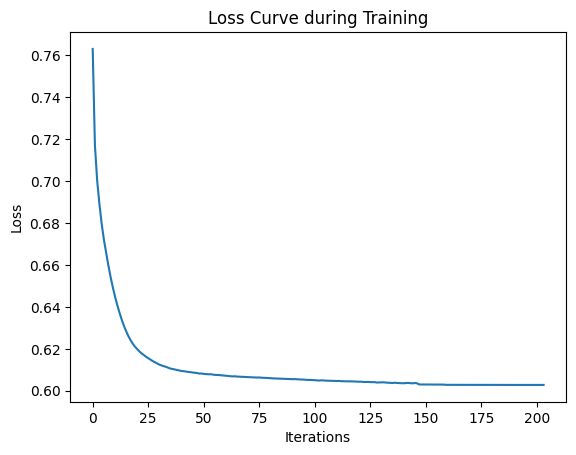

In [9]:
plt.plot(mlp1.loss_curve_)
plt.title("Loss Curve during Training")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

In [10]:
mlp2 = MLPClassifier(hidden_layer_sizes=(3,3), max_iter=100, random_state=0, solver='sgd', verbose=True,
                    alpha=0.1, momentum=0.9, batch_size=32, learning_rate='adaptive')
mlp2.fit(X_train_scaled, y_train)

Iteration 1, loss = 0.76297974
Iteration 2, loss = 0.71705657
Iteration 3, loss = 0.70031899
Iteration 4, loss = 0.68928216
Iteration 5, loss = 0.67998041
Iteration 6, loss = 0.67231603
Iteration 7, loss = 0.66603265
Iteration 8, loss = 0.66006124
Iteration 9, loss = 0.65454046
Iteration 10, loss = 0.64960960
Iteration 11, loss = 0.64509950
Iteration 12, loss = 0.64109400
Iteration 13, loss = 0.63743441
Iteration 14, loss = 0.63411539
Iteration 15, loss = 0.63110105
Iteration 16, loss = 0.62853876
Iteration 17, loss = 0.62618674
Iteration 18, loss = 0.62420725
Iteration 19, loss = 0.62247759
Iteration 20, loss = 0.62107176
Iteration 21, loss = 0.61988497
Iteration 22, loss = 0.61878070
Iteration 23, loss = 0.61780114
Iteration 24, loss = 0.61704685
Iteration 25, loss = 0.61621349
Iteration 26, loss = 0.61552586
Iteration 27, loss = 0.61478893
Iteration 28, loss = 0.61415798
Iteration 29, loss = 0.61358138
Iteration 30, loss = 0.61300858
Iteration 31, loss = 0.61244905
Iteration 32, los

c:\Users\yuhui\OneDrive - Nanyang Technological University\Y2S2\BC2407 - Analytics II Advanced Predictive Techniques\Group Project\bc2407\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.



MLPClassifier(alpha=0.1, batch_size=32, hidden_layer_sizes=(3, 3),
              learning_rate='adaptive', max_iter=100, random_state=0,
              solver='sgd', verbose=True)

In [11]:
y_pred = mlp2.predict(X_test_scaled)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

mean_accuracy = accuracy_score(y_test, y_pred)
print(f"Mean Accuracy: {mean_accuracy:.7f}")

f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1 Score: {f1:.7f}")

y_pred_prob = mlp2.predict_proba(X_test_scaled)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"AUC: {auc_score:.7f}")

Classification Report:
               precision    recall  f1-score   support

       False       0.66      0.76      0.71       789
        True       0.73      0.63      0.68       828

    accuracy                           0.69      1617
   macro avg       0.70      0.69      0.69      1617
weighted avg       0.70      0.69      0.69      1617

Confusion Matrix:
 [[598 191]
 [306 522]]
Mean Accuracy: 0.6926407
F1 Score: 0.6916110
AUC: 0.7417173


# Feature Importance

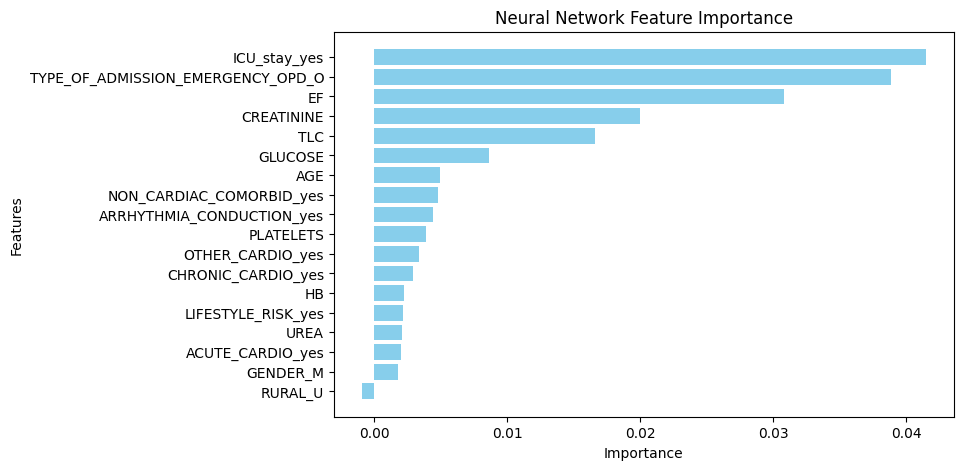

In [12]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
result = permutation_importance(mlp2, X_train_scaled, y_train, scoring='accuracy', n_repeats=10, random_state=0)

feature_importance = result.importances_mean
sorted_idx = np.argsort(feature_importance)

plt.figure(figsize=(8, 5))
plt.barh(X_train_scaled_df.columns[sorted_idx], feature_importance[sorted_idx], color="skyblue")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Neural Network Feature Importance")
plt.show()
